# Statistics for Data Science
Lecture 7  
In-class assignment 7.1  
Experiment with Beta priors and prior/posterior calculations

In [1]:
# Import packages
# in a terminal (set to your virtual environment): pip install ipywidgets prettytable

#%pip install ipywidgets
#%pip install prettytable

import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from scipy import stats
from prettytable import PrettyTable

# Step 1

In [2]:
# Create interactive plot of beta distribution (no need to be able to do this yourself at this moment)
def plot_beta(alpha=1.0, beta=1.0):
    x = np.linspace(0.001, 0.999, 1000)
    y = stats.beta(alpha,beta).pdf(x)
    
    plt.figure(figsize=(10, 4))
    plt.plot(x, y, label=f'Density of Beta({round(alpha,3)}, {round(beta,3)})')
    plt.title('Interactive plot of Beta density')
    plt.xlabel('prob')
    plt.ylabel('density')
    plt.ylim(0, y.max()*1.1)
    plt.legend()
    plt.grid(True)
    plt.show()
    
interact(
    plot_beta,
    alpha=FloatSlider(value=0.5, min=0.1, max=10.0, step=0.1, description='alpha'),
    beta =FloatSlider(value=1.0, min=0.1, max=10.0, step=0.1, description='beta')
);

interactive(children=(FloatSlider(value=0.5, description='alpha', max=10.0, min=0.1), FloatSlider(value=1.0, d…

# Questions 
(use the sliders to change alpha and beta in the plot => you can also use the arrow keys)
- When do you get a symmetric distribution?
- How do you code a belief that the probability is above 0.8?
- You may also want to use the `stats.beta(a,b).pdf(x)`, `stats.beta(a,b).cdf(x)`, `stats.beta(a,b).rvs(n)`, `stats.beta(a,b).ppf(q)`, and `stats.beta(a,b).mean()` functions
- How do you code a belief that the probability is extreme (close to 0 or close to 1)?

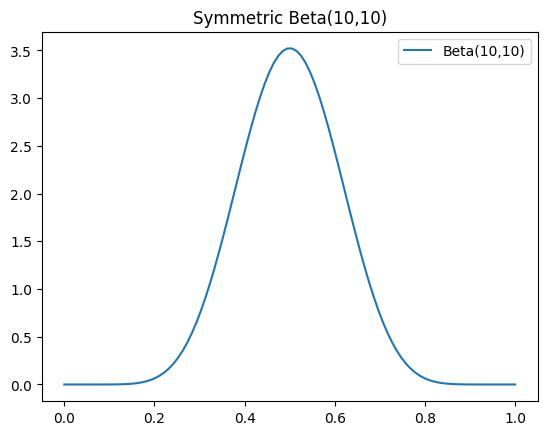

In [33]:
#Wanneer a = b.
from scipy.stats import beta
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 1, 100)
plt.plot(x, beta.pdf(x, 10, 10), label='Beta(10,10)')
plt.title("Symmetric Beta(10,10)")
plt.legend()    
plt.show()


In [ ]:
#Bereken P(X > 0.8) voor Beta(a=2, b=5)
a = 8
b = 4
prob =  1 - beta.cdf(0.8, a, b)
print(f"P(X > 0.8) for Beta({a},{b}) is: {prob:.4f}")


P(X > 0.8) for Beta(5,5) is: 0.0196


🔹 3. Hoe codeer je een belief dat de kans extreem is (dicht bij 0 of 1)?

Gebruik lage waarden van a en b (< 1).

    1.  Beta(0.5, 0.5): pieken bij 0 en 1 (extreme beliefs).
Gebruik zeer ongelijke waarden van a en b.

    1. Beta(10,1): sterk geloof dat p bijna 1 is.
    2. Beta(1,10): sterk geloof dat p bijna 0 is.

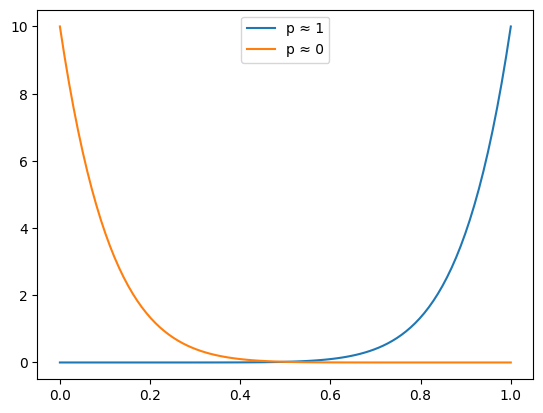

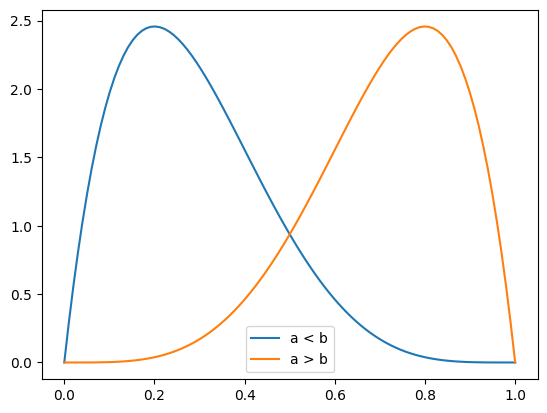

In [ ]:
plt.plot(x, beta.pdf(x, 10, 1), label='p ≈ 1')
plt.plot(x, beta.pdf(x, 1, 10), label='p ≈ 0')
plt.legend(); plt.show()

plt.plot(x, beta.pdf(x, 2, 5), label='a < b')
plt.plot(x, beta.pdf(x, 5, 2), label='a > b')
plt.legend(); plt.show()

| Functie             | Betekenis                           |
| :------------------ | :---------------------------------- |
| `beta.pdf(x, a, b)` | Waarschijnlijkheidsdichtheid (vorm) |
| `beta.cdf(x, a, b)` | Kans dat p ≤ x                      |
| `beta.ppf(q, a, b)` | Waarde van p waarvoor CDF = q       |
| `beta.rvs(a, b, n)` | Trek n willekeurige waarden         |
| `beta.mean(a, b)`   | Verwachte waarde ( \frac{a}{a+b} )  |


# Step 2

Data: [0 1 1 1 1 1 0 1 0 1 0 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 0 1 0 1 1 0 0 1 1 1 1
 1 0 0 0 1 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 0 0 1 1 1 1 1 1 0 1 0 1 0 1 1 0
 1 1 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 0 0 0 1 0 1 0 0 1]


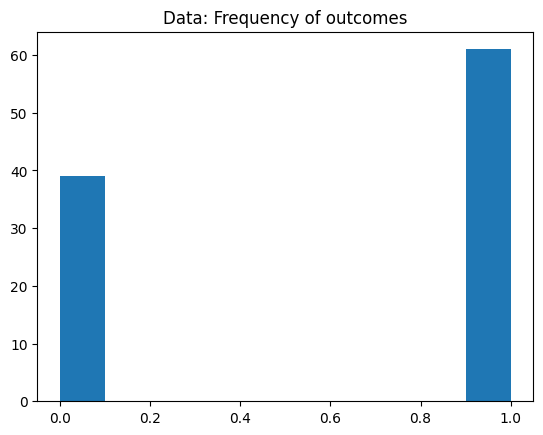

In [27]:
# Create some data from a Bernouilli distribution
np.random.seed(12345) # To ensure reproducability

N = 100
p_true = 0.7
data = stats.binom(p=p_true, n=1).rvs(N)
print("Data:", data)

plt.hist(data)
plt.title("Data: Frequency of outcomes");

Maximum likelihood/frequentist estimator of probability of heads equals

Mean of data: 0.61
Posterior parameters: a = 63, b = 41


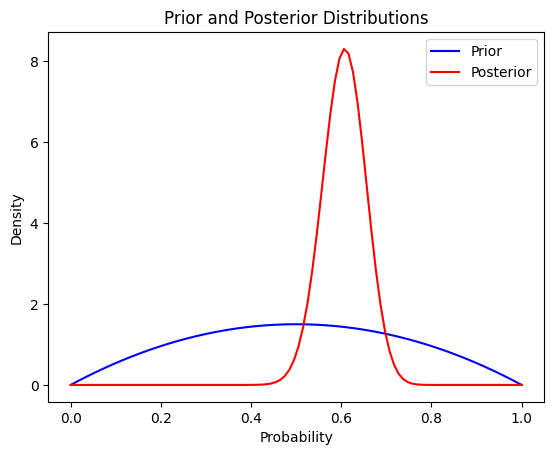

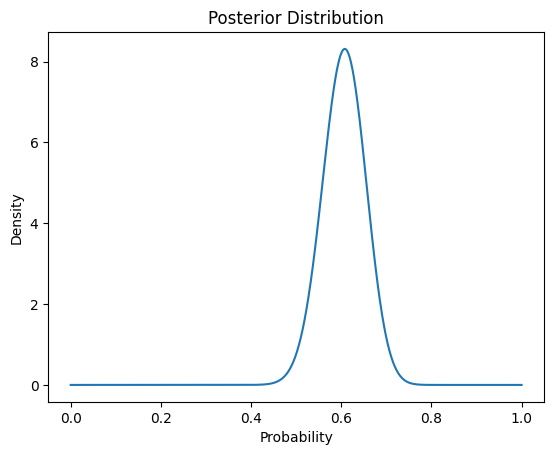

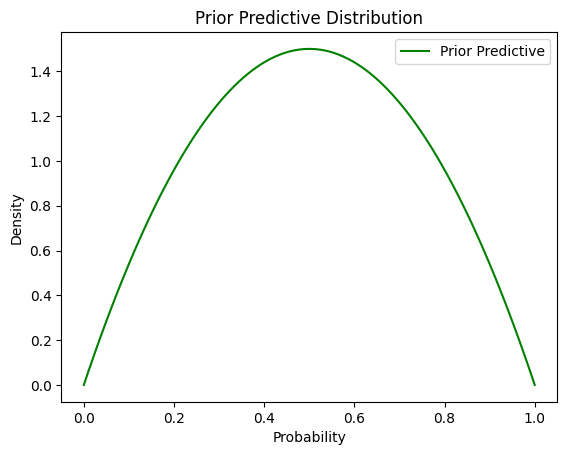

In [31]:
data.mean()
print ("Mean of data:", data.mean())
# Prior parameters
a_prior = 2
b_prior = 2 

# Posterior parameters
a_post = a_prior + data.sum()
b_post = b_prior + N - data.sum()
print(f"Posterior parameters: a = {a_post}, b = {b_post}")  

# Plot prior and posterior
x = np.linspace(0, 1, 100)
plt.plot(x, beta.pdf(x, a_prior, b_prior), label='Prior', color='blue')
plt.plot(x, beta.pdf(x, a_post, b_post), label='Posterior', color='red')
plt.title("Prior and Posterior Distributions")
plt.xlabel("Probability")
plt.ylabel("Density")
plt.legend()
plt.show()
x = np.linspace(0, 1, 1000)
plt.plot(x, beta.pdf(x, a_post, b_post))
plt.title("Posterior Distribution")
plt.xlabel("Probability")
plt.ylabel("Density")
plt.show()
# Prior predictive distribution
a_prior = 2
b_prior = 2
prior_pred = stats.beta(a_prior, b_prior)
x = np.linspace(0, 1, 100)
plt.plot(x, prior_pred.pdf(x), label='Prior Predictive', color='green')
plt.title("Prior Predictive Distribution")
plt.xlabel("Probability")
plt.ylabel("Density")
plt.legend()
plt.show()


In [ ]:
# Some code to create an interactive plot of prior, likelihood and posterior (no need to understand details)

def log_likelihood(p):
   return np.sum(np.log(p)*data + np.log(1-p)*(1-data))

def plot_posterior(alpha=1.0, beta=1.0):
    x = np.linspace(0.001, 0.999, 1000)   
    prior = stats.beta(alpha,beta)
    priorpdf = prior.pdf(x)
    
    plt.figure(figsize=(10, 4))
    plt.plot(x, priorpdf, label=f'Prior Beta({round(alpha,3)}, {round(beta,3)})')
    # plt.title('Interactive plot of Beta density')
      
    llik = [log_likelihood(p) for p in x]

    llik = llik - np.max(llik) + np.log(stats.beta(data.sum(), data.size - data.sum()).pdf(data.mean()))
    lik  = np.exp(llik)
    
    plt.plot(x, lik, label=f'Likelihood (scaled)')
    
    posterior = stats.beta(alpha +data.sum(), beta + data.size - data.sum())
    posteriorpdf = posterior.pdf(x)
    plt.plot(x, posteriorpdf, label=f'Posterior')
    
    table = PrettyTable()
    table.field_names = ['', "Point estimate", "Est.Var", "Est.Std", "Interval Low", "Interval High"]
    table.add_row(["Prior", prior.mean(), prior.var(), prior.std(), prior.ppf(0.025), prior.ppf(0.975)])
    table.add_row(["Posterior", posterior.mean(), posterior.var(), posterior.std(), posterior.ppf(0.025), posterior.ppf(0.975)])
    
    stderrmean = np.sqrt(data.var(ddof=1)/data.size)
    table.add_row(["Frequentist", data.mean(), stderrmean**2, stderrmean, data.mean() - stats.t(data.size-1).ppf(0.975)*stderrmean, data.mean() + stats.t(data.size-1).ppf(0.975)*stderrmean])
    table.float_format = ".3"
    
    print("Estimation statistics")
    print(table)
    
    plt.xlabel('prob')
    plt.ylabel('density')
    plt.title('Prior (blue) x Likelihood (orange) = Posterior (green)')
    plt.ylim(0, np.max([priorpdf.max(), posteriorpdf.max(), lik.max()])*1.1)
    plt.legend()
    plt.grid(True)
    plt.show()
    
interact(
    plot_posterior,    
    alpha=FloatSlider(value=0.5, min=0.1, max=100.0, step=0.1, description='alpha'),
    beta=FloatSlider(value=1.0, min=0.1, max=100.0, step=0.1, description='beta')
);

interactive(children=(FloatSlider(value=0.5, description='alpha', min=0.1), FloatSlider(value=1.0, description…


# Questions
- For what setting of alpha and beta does the posterior mean equal the frequentist estimator?
- What happens when alpha=beta=high?
- What happens when alpha=large and beta=small?

In [1]:
#%pip install bambi
